# **PyTorch workflow**

Let's explore an example PyTorch end-to-end workflow

`data (prepare and load) -> build model -> fitting the model to data (training) -> making predictions and evaluating a model (inference) -> saving and loading a model -> putting it all together`

In [27]:
import torch
from torch import nn    # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

## 1. Data (preparing and loading)

Data can be almost anything.
* Excel spreadsheets
* Images
* Videos
* Audio
* Text
* etc.

Machine learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some *known* data using the lineaer regression formula.

We'll use a linear regression formula to make a straight line with known **parameters**

In [28]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [29]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets

In [30]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualiza our data?

In [31]:
def plot_predictions(train_data = X_train, train_labels = y_train, test_data = X_test, test_labels = y_test, predictions = None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c = "b", s = 4, label = "Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c = "g", s = 4, label = "Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c = "r", s = 4, label = "Predictions")

    plt.legend(prop={"size": 14})

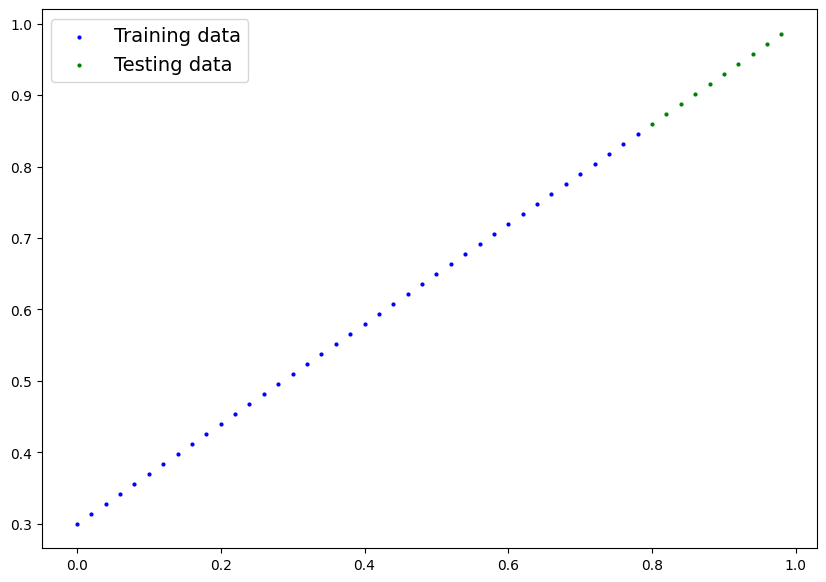

In [32]:
plot_predictions()

## 2. Building model

What this model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent the ideal values

How?:
1. Gradient descent
2. Backpropagation

In [33]:
# Create a linear regression model class
class LinearRegressionModel(nn.Module):     # <- almost everything in PyTorch inherist from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad = True,dtype = torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad = True, dtype = torch.float))

    #Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias     # Linear regression formula

### PyTorch model building essentials

* torch.nn - contains all of of the buildings for computational graphs
* torch.nn.Parameter - what parameters should our model try and learn, ofter a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - the base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this where the optimizers in PyTorch live, they will help with gradient descent
* def forward() - all nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computations

###  Checking the contents of our PyTorch model

In [34]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out thte parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [35]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_model()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`.

When we pass data through our model, it's going to run it through the forward() method.

In [38]:
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [39]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

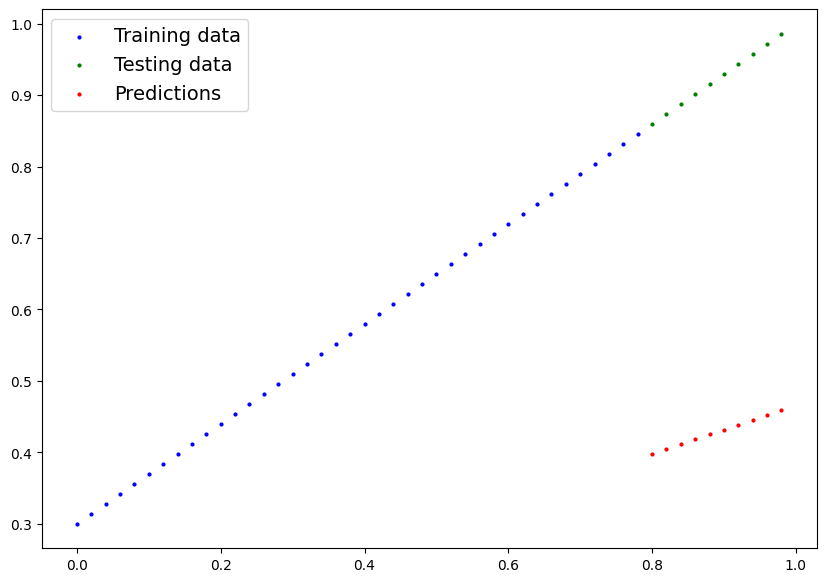

In [40]:
plot_predictions(predictions = y_preds)

### 3. Train model